In [ ]:
import pickle

with open("WDM_dataset/Interim/S10.pkl", "rb") as f:
    data = pickle.load(f, encoding='latin1')

In [ ]:
print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['signal', 'label', 'subject'])


In [ ]:
print(data['signal'].keys())

dict_keys(['chest', 'wrist'])


In [ ]:
print(data['signal']['wrist'].keys())
print(data['signal']['chest'].keys())

dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])
dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])


In [ ]:
signals = data['signal']
wrist = signals['wrist']
eda = wrist['EDA']

In [ ]:
print(eda.shape)

(21984, 1)


In [ ]:
print(eda[:5])

[[0.349215]
 [0.346656]
 [0.350494]
 [0.336423]
 [0.338981]]


In [ ]:
# Assuming 'data' is already loaded from your pkl file
signals = data['signal']
extracted_data = {}

for location in signals.keys():  # Loops through ['chest', 'wrist']
    print(f"--- Processing {location.upper()} signals ---")
    extracted_data[location] = {}
    
    for sensor in signals[location].keys():  # Loops through ACC, EDA, etc.
        sensor_data = signals[location][sensor]
        
        # Store it for later use
        extracted_data[location][sensor] = sensor_data
        
        # Print info to verify
        print(f"Sensor: {sensor:5} | Shape: {sensor_data.shape}")

# Also grabbing the labels, which are usually at the top level
labels = data['label']
print(f"\nLabels Shape: {labels.shape}")

--- Processing CHEST signals ---
Sensor: ACC   | Shape: (3847200, 3)
Sensor: ECG   | Shape: (3847200, 1)
Sensor: EMG   | Shape: (3847200, 1)
Sensor: EDA   | Shape: (3847200, 1)
Sensor: Temp  | Shape: (3847200, 1)
Sensor: Resp  | Shape: (3847200, 1)
--- Processing WRIST signals ---
Sensor: ACC   | Shape: (175872, 3)
Sensor: BVP   | Shape: (351744, 1)
Sensor: EDA   | Shape: (21984, 1)
Sensor: TEMP  | Shape: (21984, 1)

Labels Shape: (3847200,)


In [ ]:
print(type(data['signal']))   # <class 'dict'> -> You can use .keys()
print(type(data['label']))    # <class 'numpy.ndarray'> -> No .keys()
print(type(data['subject']))  # <class 'str'> -> No .keys()

<class 'dict'>
<class 'numpy.ndarray'>
<class 'str'>


In [ ]:
# This will simply print 'S10'
print("Subject ID:", data['subject'])

Subject ID: S10


In [ ]:
labels = data['label']
print(f"Shape of labels: {labels.shape}")

Shape of labels: (3847200,)


In [ ]:
import numpy as np

unique_labels = np.unique(labels)
print(f"Unique classes: {unique_labels}")
print(f"Number of unique classes: {len(unique_labels)}")

Unique classes: [0 1 2 3 4 5 6 7]
Number of unique classes: 8


In [ ]:
# Returns unique labels and their respective counts
classes, counts = np.unique(labels, return_counts=True)

print("Label Distribution:")
for label, count in zip(classes, counts):
    print(f"Label {label}: {count} samples")

Label Distribution:
Label 0: 1589000 samples
Label 1: 826000 samples
Label 2: 507500 samples
Label 3: 260400 samples
Label 4: 557200 samples
Label 5: 35700 samples
Label 6: 31500 samples
Label 7: 39900 samples


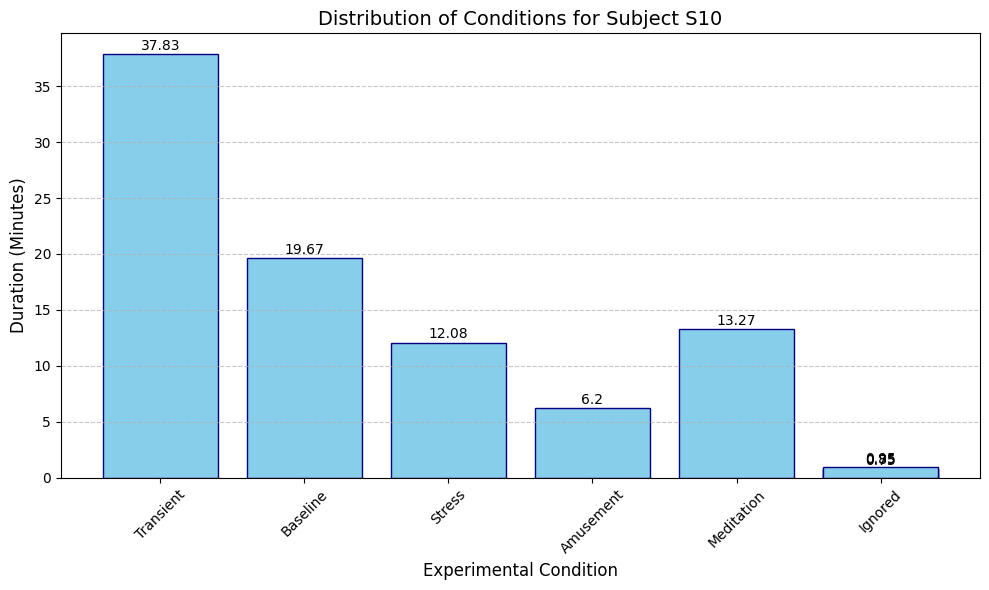

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Map the numeric labels to their actual names
label_map = {
    0: 'Transient',
    1: 'Baseline',
    2: 'Stress',
    3: 'Amusement',
    4: 'Meditation',
    5: 'Ignored',
    6: 'Ignored',
    7: 'Ignored'
}

labels = data['label']
classes, counts = np.unique(labels, return_counts=True)

# 2. Convert counts to minutes (Count / 700 Hz / 60 seconds)
durations_min = (counts / 700) / 60
names = [label_map[c] for c in classes]

# 3. Create the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(names, durations_min, color='skyblue', edgecolor='navy')

# Add styling
plt.title('Distribution of Conditions for Subject S10', fontsize=14)
plt.xlabel('Experimental Condition', fontsize=12)
plt.ylabel('Duration (Minutes)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Optional: Add the exact value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('label_distribution.png')